# 03 - Modeling, evaluation and explainability

Models are trained by `src/modeling/train.py` (run through the pipeline). This notebook reads the saved
results so the numbers here are exactly what the pipeline produced.

In [1]:
import sys, json, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import Image, display
from src.db import read_sql
from src.evaluation import plots  # applies the shared chart style
pd.set_option("display.max_columns", 30); pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
FIG = Path("../reports/figures")
R = json.load(open("../reports/model_results.json"))

## 1. PD model - model comparison
Logistic regression, random forest and LightGBM were each tuned with the same 5-fold stratified CV on the 80%
training split. Selection uses CV ROC-AUC only; the test set is reported but was not used to choose.

In [2]:
pd.DataFrame(R["pd"]["cv_results"]).drop(columns=["best_params"]).merge(pd.DataFrame(R["pd"]["test_comparison"]), on="model")

,model,cv_roc_auc,cv_roc_auc_std,cv_pr_auc,cv_pr_auc_std,train_roc_auc,train_pr_auc,test_roc_auc,test_pr_auc,test_brier
0,logistic_regression,0.7768,0.0045,0.5419,0.0070,0.7803,0.5461,0.7701,0.5335,0.1377
1,random_forest,0.7886,0.0046,0.5604,0.0069,0.8151,0.6092,0.7826,0.5663,0.1343
2,lightgbm,0.7893,0.0046,0.5645,0.0044,0.8202,0.6140,0.7847,0.5658,0.1337


LightGBM and the random forest are almost tied and both beat logistic regression by about 0.013 AUC.
The train-vs-CV gap (about 0.03) shows mild overfitting, which is acceptable. LightGBM was selected.
Its raw probabilities were already well calibrated, so no calibration layer was added:

In [3]:
pd.DataFrame(R["pd"]["calibration_table"])

,method,brier,ece,mean_predicted,base_rate
0,none,0.1325,0.0058,0.2209,0.2212
1,sigmoid,0.1325,0.0056,0.2210,0.2212
2,isotonic,0.1326,0.0075,0.2211,0.2212


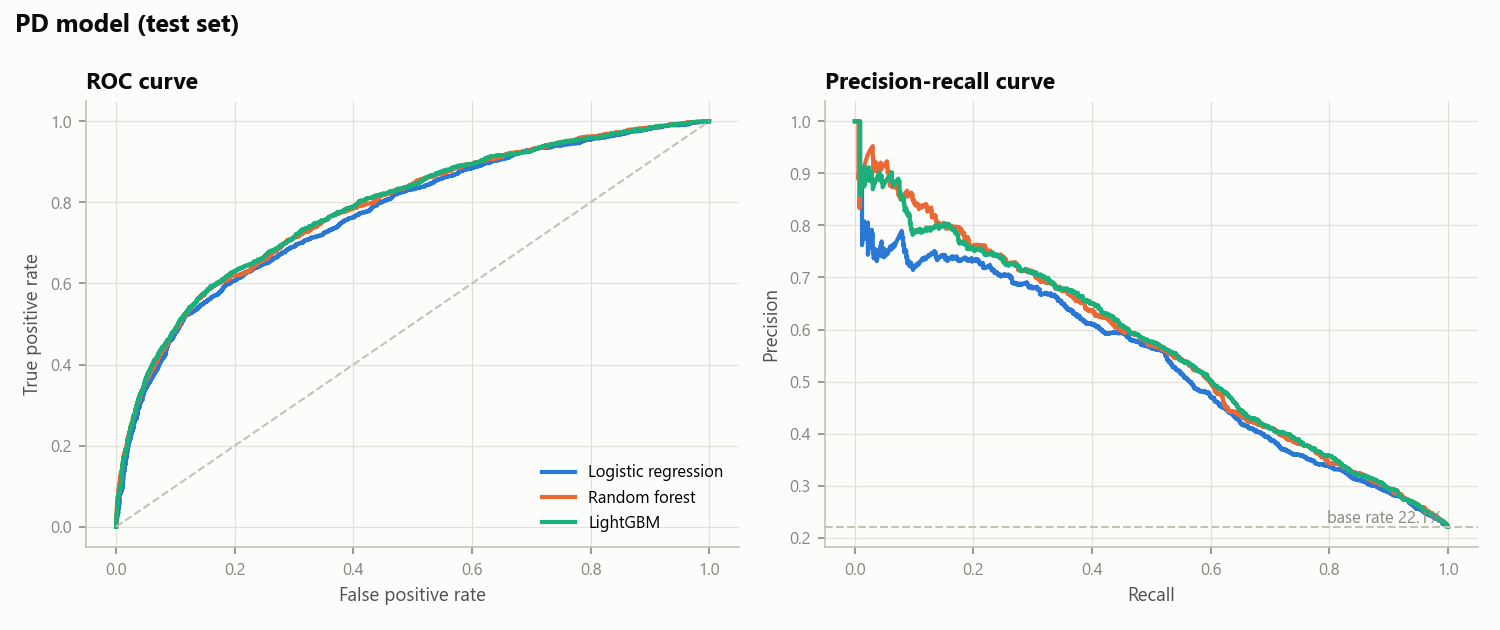

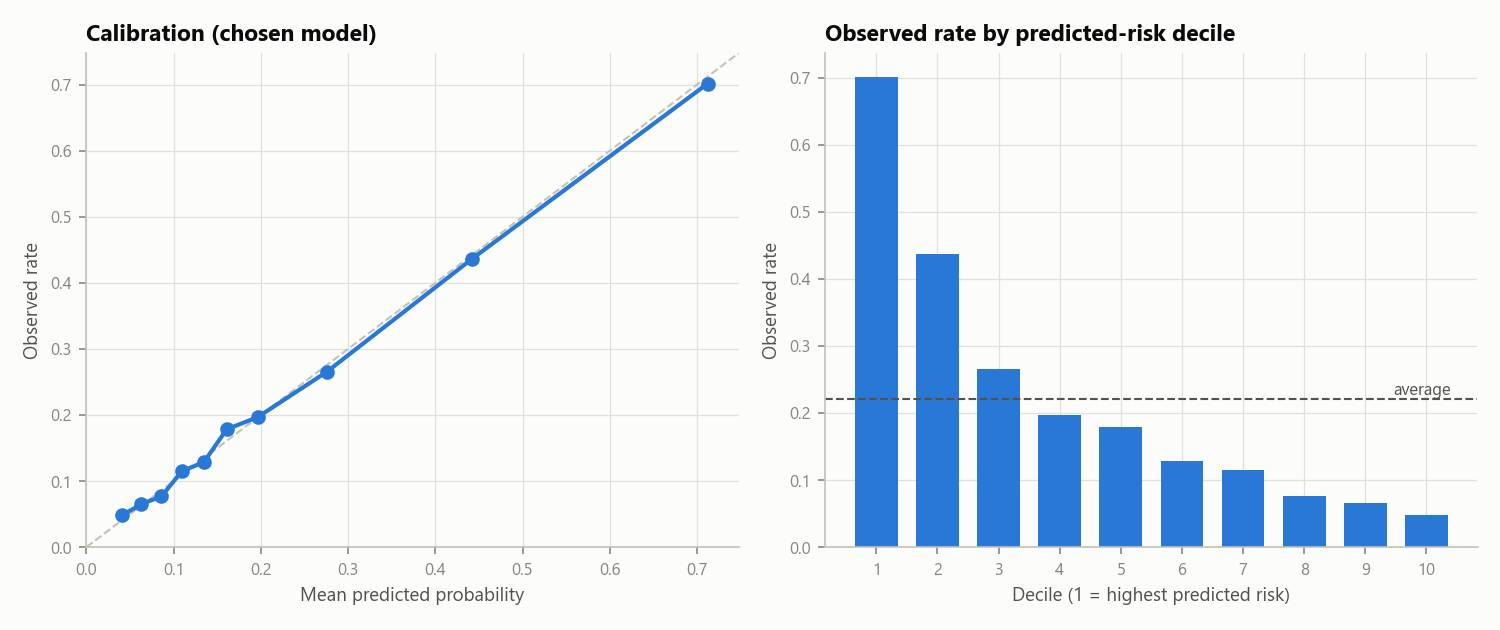

In [4]:
display(Image(FIG / "pd_roc_pr.png")); display(Image(FIG / "pd_calibration_lift.png"))

In [5]:
pd.DataFrame(R["pd"]["lift"])

,decile,n,positives,mean_predicted,observed_rate,lift,cum_capture
0,1,600,421,0.7123,0.7017,3.1726,0.3173
1,2,600,262,0.4425,0.4367,1.9744,0.5147
2,3,600,159,0.2753,0.2650,1.1982,0.6345
3,4,600,118,0.1962,0.1967,0.8892,0.7234
4,5,600,107,0.1609,0.1783,0.8063,0.8041
5,6,600,77,0.1344,0.1283,0.5803,0.8621
6,7,600,69,0.1094,0.1150,0.5200,0.9141
7,8,600,46,0.0860,0.0767,0.3466,0.9488
8,9,600,39,0.0630,0.0650,0.2939,0.9781
9,10,600,29,0.0410,0.0483,0.2185,1.0000


## 2. Choosing a threshold
Probabilities feed the expected-loss calculation directly, but a risk team acting on a flag needs a cut-off.
With calibrated probabilities the cost-minimizing threshold is `C_FP / (C_FP + C_FN)`. C_FN (average loss on a
missed defaulter) comes from the data and assumptions; C_FP (cost of acting on a good customer) is unknown, so
I show a range:

In [6]:
pd.DataFrame(R["pd"]["cost_table"])

,c_fp,c_fn,threshold,share_flagged,precision,recall,expected_cost_per_customer
0,500,"1,531.6709",0.2461,0.2728,0.4924,0.6074,202.2501
1,2000,"1,531.6709",0.5663,0.1082,0.6872,0.3361,292.5670
2,5000,"1,531.6709",0.7655,0.0223,0.8284,0.0836,329.5853


In [7]:
pd.DataFrame(R["pd"]["thresholds"])

,threshold,share_flagged,precision,recall,tp,fp,fn
0,0.1000,0.6872,0.2927,0.9096,1207,2916,120
1,0.2000,0.3395,0.4315,0.6624,879,1158,448
2,0.3000,0.2283,0.5380,0.5554,737,633,590
3,0.4000,0.1647,0.6073,0.4521,600,388,727
4,0.5000,0.1235,0.6694,0.3738,496,245,831
5,0.6000,0.0997,0.7023,0.3165,420,178,907
6,0.7000,0.0533,0.7656,0.1846,245,75,1082
7,0.8000,0.0075,0.8889,0.0301,40,5,1287
8,0.9000,0.0000,NaN,0.0000,0,0,1327


The threshold depends heavily on the false-positive cost, which is a business input, not a modeling one.
At 0.5 the model flags about 12% of customers with roughly two-thirds precision; at 0.3 it catches more than
half of defaulters at about 54% precision.

## 3. Fairness check
Sex is not a model input. Are predictions still calibrated within each group?

In [8]:
pd.DataFrame(R["pd"]["fairness"])

,sex,customers,actual_default_rate,mean_pd
0,Female,18112,0.2078,0.2121
1,Male,11888,0.2417,0.2344


## 4. Dormancy model
Same candidates plus a class-weighted LightGBM. Selection by CV PR-AUC on the May snapshot; the test is the
July snapshot (out-of-time).

In [9]:
pd.DataFrame(R["churn"]["cv_results"]).drop(columns=["best_params"]).merge(pd.DataFrame(R["churn"]["test_comparison"]), on="model")

,model,cv_roc_auc,cv_roc_auc_std,cv_pr_auc,cv_pr_auc_std,train_roc_auc,train_pr_auc,test_roc_auc,test_pr_auc,test_brier
0,logistic_regression,0.8878,0.0157,0.1286,0.0196,0.8926,0.1310,0.9034,0.1163,0.0113
1,random_forest,0.8910,0.0208,0.1588,0.0298,0.9721,0.3838,0.8996,0.1082,0.0113
2,lightgbm,0.8950,0.0179,0.1458,0.0281,0.9626,0.4262,0.9112,0.1318,0.0111
3,lightgbm_weighted,0.8889,0.0212,0.1415,0.0246,0.9854,0.4329,0.9092,0.1300,0.0632


The random forest had the best CV PR-AUC, but the CV standard deviations (~0.03) are larger than the gaps
between models, and on the out-of-time test LightGBM did better. I kept the CV-based choice: switching after
seeing the test results would make the test estimate optimistic. With more months of data I would select
models with rolling out-of-time validation. Class weighting did not improve ranking and wrecked calibration
(test Brier 0.063 vs 0.011).

In [10]:
print({k: round(v, 4) for k, v in R["churn"]["test_metrics"]["at_top_10pct"].items() if isinstance(v, float)})
pd.DataFrame(R["churn"]["lift"])

{'base_rate': 0.0121, 'roc_auc': 0.8996, 'gini': 0.7992, 'pr_auc': 0.1082, 'brier': 0.0113, 'log_loss': 0.0498, 'mean_predicted': 0.0152, 'threshold': 0.0474, 'precision': 0.0821, 'recall': 0.678, 'f1': 0.1464}


,decile,n,positives,mean_predicted,observed_rate,lift,cum_capture
0,1,2669,219,0.1010,0.0821,6.7779,0.6780
1,2,2668,52,0.0296,0.0195,1.6100,0.8390
2,3,2668,30,0.0120,0.0112,0.9288,0.9319
3,4,2668,8,0.0048,0.0030,0.2477,0.9567
4,5,2668,1,0.0021,0.0004,0.0310,0.9598
5,6,2668,6,0.0010,0.0022,0.1858,0.9783
6,7,2668,3,0.0006,0.0011,0.0929,0.9876
7,8,2668,3,0.0003,0.0011,0.0929,0.9969
8,9,2668,0,0.0002,0.0000,0.0000,0.9969
9,10,2668,1,0.0001,0.0004,0.0310,1.0000


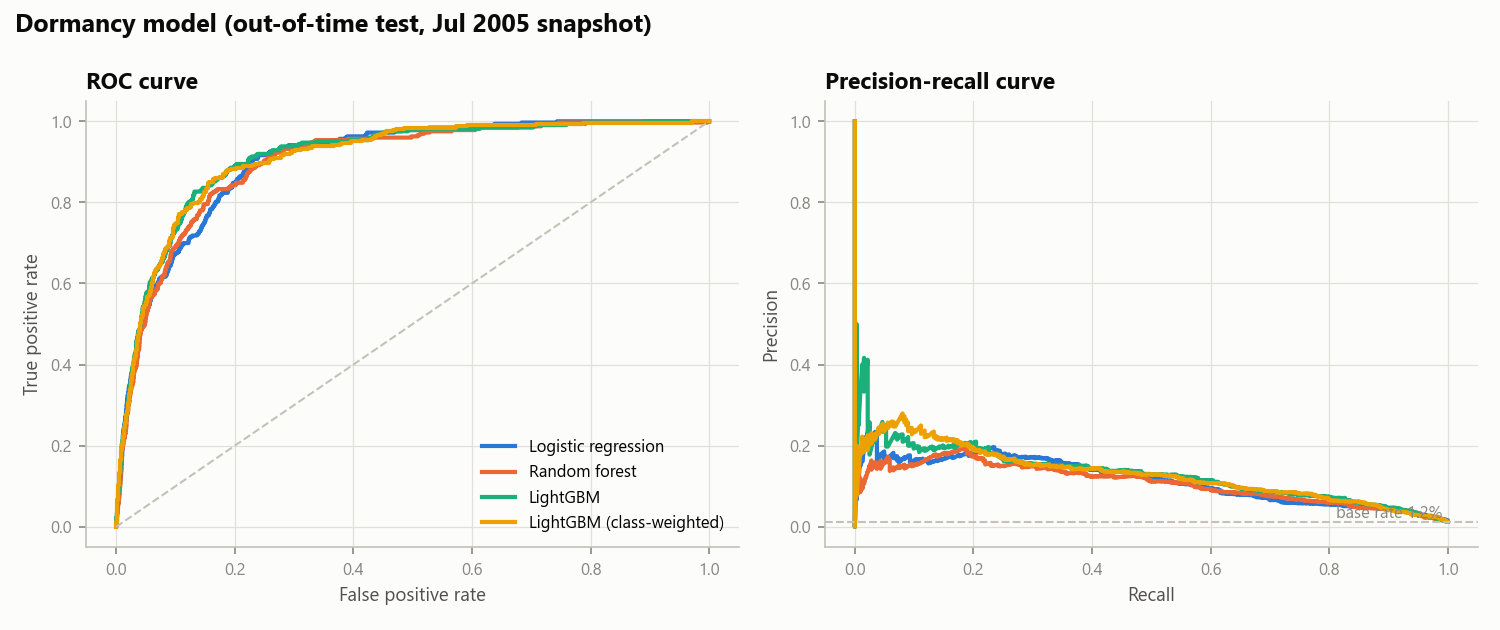

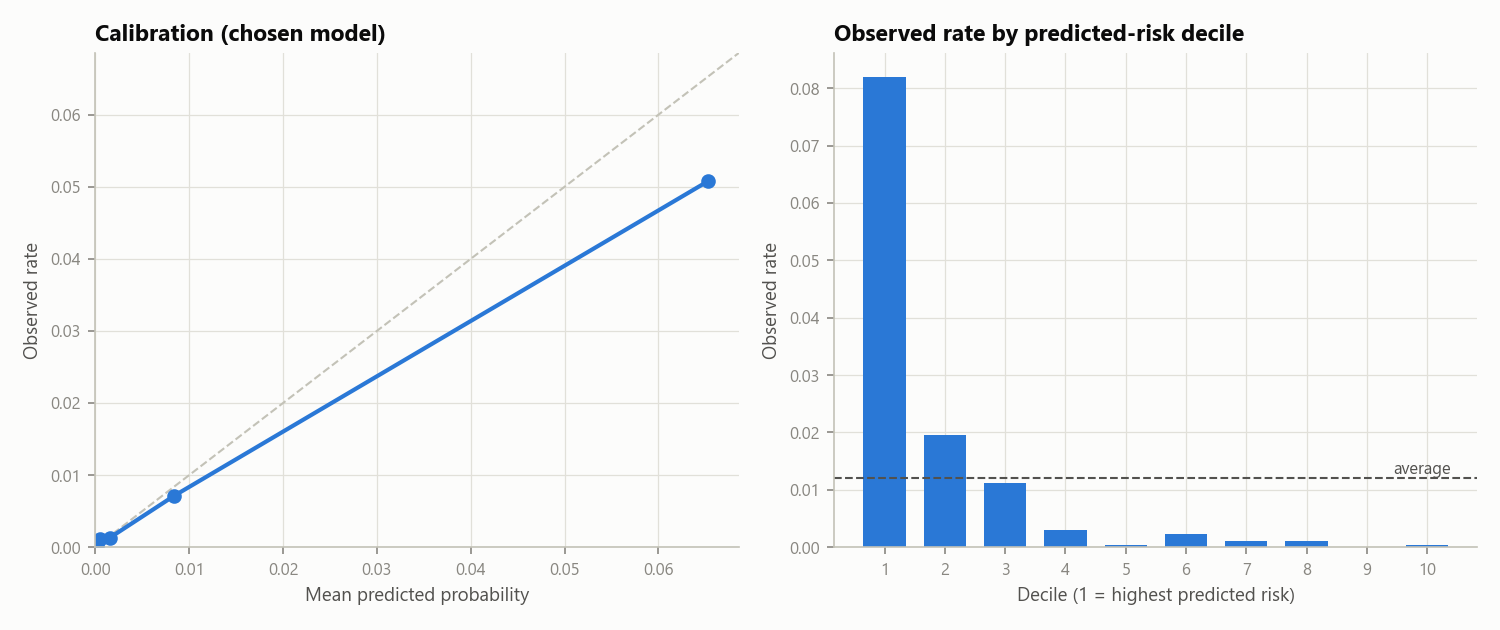

In [11]:
display(Image(FIG / "churn_roc_pr.png")); display(Image(FIG / "churn_calibration_lift.png"))

Contacting the top 10% of active customers by predicted risk would reach about two-thirds of the customers
who actually went dormant. Precision is low in absolute terms (~8%) because the event is rare, but that is
about 7x the base rate. Mean predicted probability on the test snapshot is a little above the observed rate,
because dormancy was more common in May (training) than in July.

## 5. Explainability (SHAP)

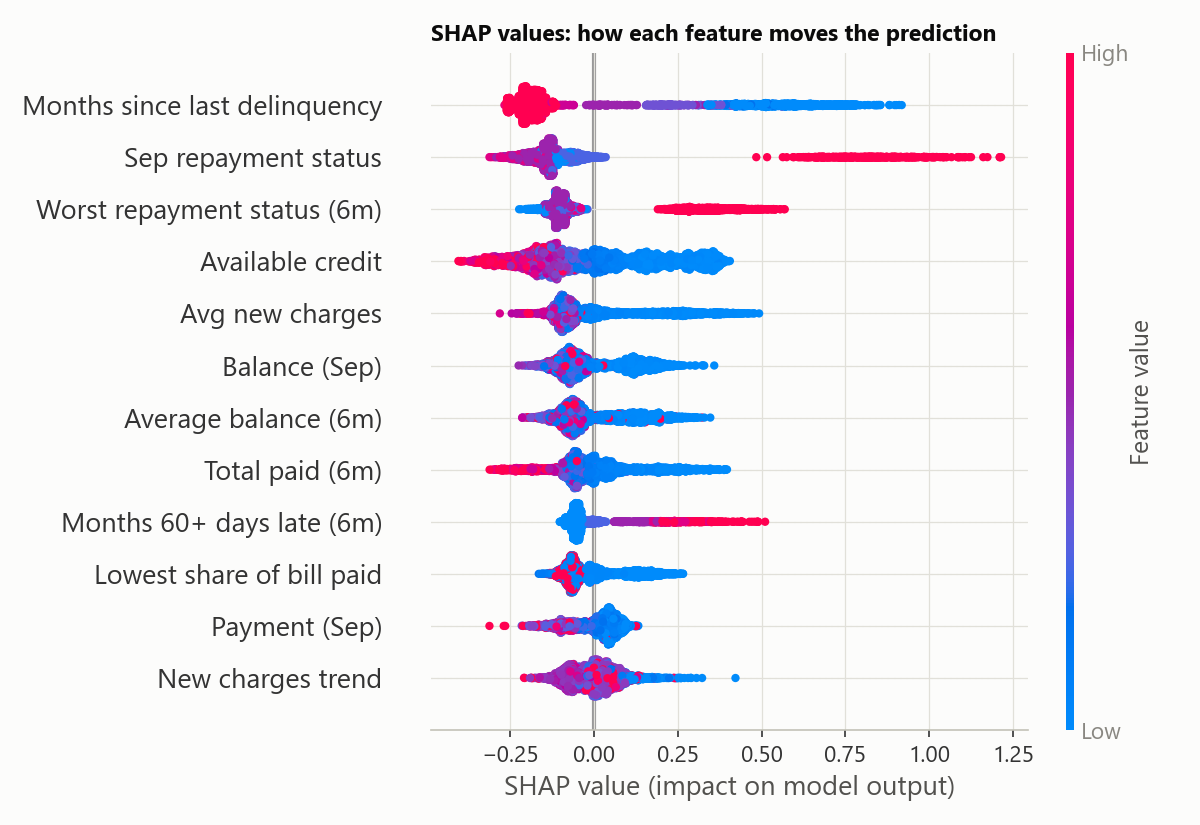

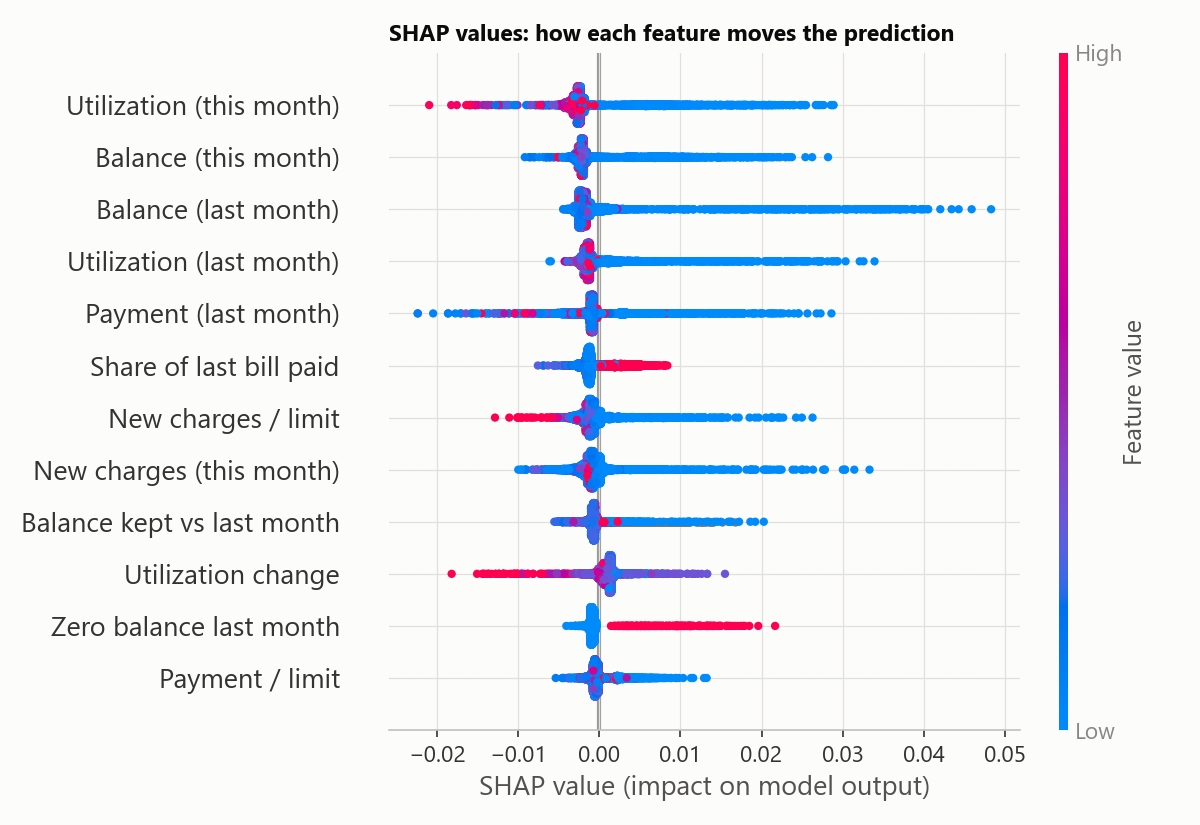

In [12]:
display(Image(FIG / "pd_shap_beeswarm.png")); display(Image(FIG / "churn_shap_beeswarm.png"))

**PD:** recent delinquency dominates (months since last delinquency, September status, worst status), followed
by available credit and spending. Low available credit and recent late payments push risk up; paying a larger
share of the bill and having headroom on the limit push it down.

**Dormancy:** small and shrinking balances, low utilization and paying off most of the bill push the prediction
up - these are customers winding the card down. These are associations the model learned, not causes.

### Local explanations for individual customers
Reason codes list up to three features pushing the prediction up and two pushing it down; features carrying
less than 5% of the customer's total SHAP attribution are left out so that negligible effects aren't shown as
reasons. Examples: the riskiest customer, a customer near 25% PD and the safest customer.

In [13]:
ex = read_sql('''SELECT customer_id, round(pd_score::numeric, 3) pd, pd_risk_band, pd_drivers_up, pd_drivers_down
                FROM ml.pd_scores WHERE customer_id IN (
                  (SELECT customer_id FROM ml.pd_scores ORDER BY pd_score DESC LIMIT 1),
                  (SELECT customer_id FROM ml.pd_scores ORDER BY abs(pd_score - 0.25) LIMIT 1),
                  (SELECT customer_id FROM ml.pd_scores ORDER BY pd_score LIMIT 1))''')
for r in ex.itertuples():
    print(f"Customer {r.customer_id}: PD {r.pd:.1%} ({r.pd_risk_band})\n  raises risk: {r.pd_drivers_up}\n  lowers risk: {r.pd_drivers_down}\n")

Customer 6877: PD 1.4% (1. Low (<10%))
  raises risk: 
  lowers risk: Education: Unknown; Available credit: NT$319,750

Customer 11824: PD 25.0% (2. Medium (10-30%))
  raises risk: Available credit: NT$0; Average balance (6m): NT$343,238; Utilization (Sep): 100%
  lowers risk: Sep repayment status: revolving, current; Months since last delinquency: 6

Customer 12019: PD 88.7% (4. Very high (50%+))
  raises risk: Months since last delinquency: 0; Sep repayment status: 2 month(s) late; Worst repayment status (6m): 2 month(s) late
  lowers risk: 



In [14]:
ex = read_sql('''SELECT customer_id, churn_score, churn_drivers_up, churn_drivers_down
                FROM ml.churn_scores ORDER BY churn_score DESC LIMIT 3''')
for r in ex.itertuples():
    print(f"Customer {r.customer_id}: P(dormant in Oct-Nov) {r.churn_score:.1%}\n  raises: {r.churn_drivers_up}\n  lowers: {r.churn_drivers_down}\n")

Customer 14005: P(dormant in Oct-Nov) 30.4%
  raises: Balance (last month): NT$0; Utilization (last month): 0%; Utilization (this month): 1%
  lowers: 

Customer 16828: P(dormant in Oct-Nov) 30.0%
  raises: Balance (last month): NT$0; Utilization (last month): 0%; Balance (this month): NT$1,000
  lowers: 

Customer 10304: P(dormant in Oct-Nov) 29.1%
  raises: Balance (last month): NT$0; Utilization (last month): 0%; Utilization (this month): 1%
  lowers: 



**Next:** segmentation, profitability and retention (`04_business_analysis.ipynb`).